In [27]:
# Base directory containing all batches for epoch_0
run_dir = "runs/superbench/online/react-adapt/epoch_0"

# Baseline directory (if available) and analysis output path
base_run_dir = "runs/superbench/test/react-base/"
analysis_out_path = "analysis/superbench/online/batchmetrics.json"
# Batches follow the pattern: run_dir/batch_<idx> where idx in [0..44]


In [28]:
import os
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed
from utils.updatables import SmartFieldManager

from pydantic import BaseModel, field_validator
from benchmarks.superbench.super_program import SuperReactAgent , close_runtime_tools, ProgramResult, get_super_react_fm
from benchmarks.superbench.super_utils import metric_aggregator
from tqdm import tqdm
import json
import tiktoken


In [29]:
# Helper to find the instance_id within a batch directory (subdir containing score.json)
def find_instance_id(batch_dir: str) -> str | None:
    for entry in os.scandir(batch_dir):
        if entry.is_dir():
            score_path = os.path.join(entry.path, "score.json")
            if os.path.exists(score_path):
                return os.path.basename(entry.path)
    return None

# Load a ProgramResult for a given batch and instance_id
def load_program_result(batch_dir: str, instance_id: str, fm: SmartFieldManager) -> ProgramResult | None:
    instance_logger = logging.getLogger(f"loader.{os.path.basename(batch_dir)}")
    instance_logger.setLevel(logging.INFO)
    program = SuperReactAgent(
        fm=fm,
        base_dir=batch_dir,
        model_name="super-react",
        max_iter=0,
        max_time=0,
        logger=instance_logger
    )
    loaded = program.load_results(instance_id=instance_id, instance=None)
    if loaded:
        # Score is loaded from score.json; recompute only if needed.
        # program.get_score(from_messages=False)
        return program.program_result
    return None

# Token counter using tiktoken (cl100k_base)
_encoding = tiktoken.get_encoding("cl100k_base")
def token_count(text: str | None) -> int:
    if not text:
        return 0
    return len(_encoding.encode(text))

# Prepare FM and aggregate batch metrics for batches 0..44
fm = get_super_react_fm()
batch_metrics = {}

for i in tqdm(range(0, 45), desc="Collecting batch metrics"):
    batch_dir = os.path.join(run_dir, f"batch_{i}")
    if not os.path.isdir(batch_dir):
        continue

    instance_id = find_instance_id(batch_dir)
    if not instance_id:
        continue

    pr = load_program_result(batch_dir, instance_id, fm)

    # Read fm_before and fm_after
    fb_path = os.path.join(batch_dir, "fm_before.txt")
    fa_path = os.path.join(batch_dir, "fm_after.txt")
    try:
        with open(fb_path, "r", encoding="utf-8") as f:
            fmbefore = f.read()
    except Exception:
        fmbefore = ""
    try:
        with open(fa_path, "r", encoding="utf-8") as f:
            fmafter = f.read()
    except Exception:
        fmafter = ""

    batch_metrics[i] = {
        "batch_dir": batch_dir,
        "instance_id": instance_id,
        "score": (pr.score if pr else None),
        "fmbefore": fmbefore,
        "fmbefore_tokens": token_count(fmbefore),
        "fmafter": fmafter,
        "fmafter_tokens": token_count(fmafter),
    }

    # Attempt to load baseline score for the same batch/instance if available
    base_score = None
    if base_run_dir and os.path.isdir(base_run_dir):
        base_score_path = os.path.join(base_run_dir, instance_id, 'score.json')
        # print(base_score_path)
        if os.path.exists(base_score_path):
            try:
                with open(base_score_path, 'r', encoding='utf-8') as bf:
                    base_score = json.load(bf)
            except Exception:
                base_score = None

    batch_metrics[i]['base_score'] = base_score

# Save for reuse in downstream analysis
os.makedirs(os.path.dirname(analysis_out_path), exist_ok=True)
with open(analysis_out_path, "w", encoding="utf-8") as f:
    json.dump(batch_metrics, f, indent=2, ensure_ascii=False)
print(f"Saved metrics for {len(batch_metrics)} batches to {analysis_out_path}")


Saved metrics for 45 batches to analysis/superbench/online/batchmetrics.json


In [30]:
# Quick peek at one entry
if batch_metrics:
    first_key = sorted(batch_metrics.keys())[0]
    print("Example batch", first_key)
    print({k: batch_metrics[first_key][k] for k in ["instance_id", "score", "fmbefore_tokens", "fmafter_tokens"]})
else:
    print("No batch metrics collected.")


Example batch 0
{'instance_id': 'upet', 'score': {'instance_id': 'upet', 'tool_calls_count': 76, 'submitted': 1, 'output_match': 0.0, 'landmarks': 0.0}, 'fmbefore_tokens': 245, 'fmafter_tokens': 611}


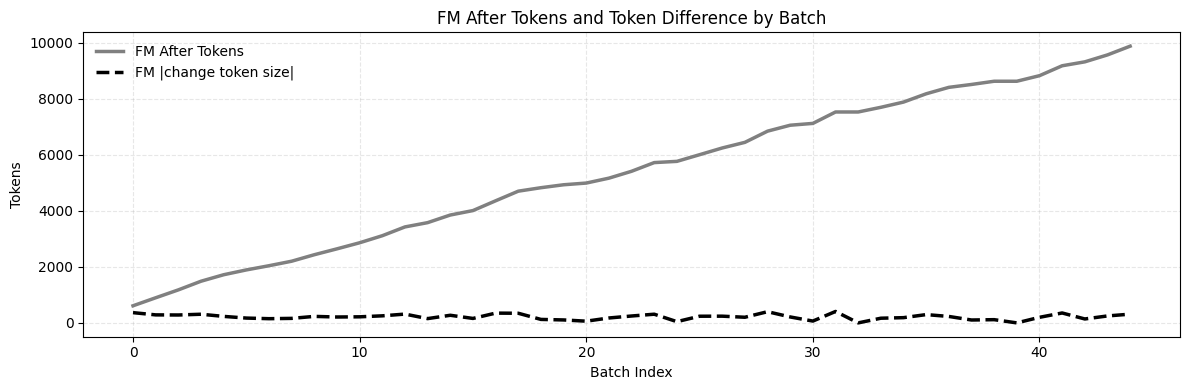

In [54]:
# FM After and FM Difference (single figure)
import matplotlib.pyplot as plt

# Ensure data is loaded
if 'batch_metrics' not in globals() or not batch_metrics:
    with open(analysis_out_path, 'r', encoding='utf-8') as f:
        batch_metrics = json.load(f)
        batch_metrics = {int(k): v for k, v in batch_metrics.items()}

xs = sorted(batch_metrics.keys())
aft_tokens, diff_tokens = [], []
for b in xs:
    e = batch_metrics[b]
    bef = float(e.get('fmbefore_tokens') or 0)
    aft = float(e.get('fmafter_tokens') or 0)
    aft_tokens.append(aft)
    diff_tokens.append(abs(aft - bef))

plt.figure(figsize=(12, 4))
plt.plot(xs, aft_tokens,  label='FM After Tokens', color='gray', linestyle='-', linewidth=2.5)
plt.plot(xs, diff_tokens, label='FM |change token size|', color='black', linestyle='--', linewidth=2.5)
plt.xlabel('Batch Index')
plt.ylabel('Tokens')
plt.title('FM After Tokens and Token Difference by Batch')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


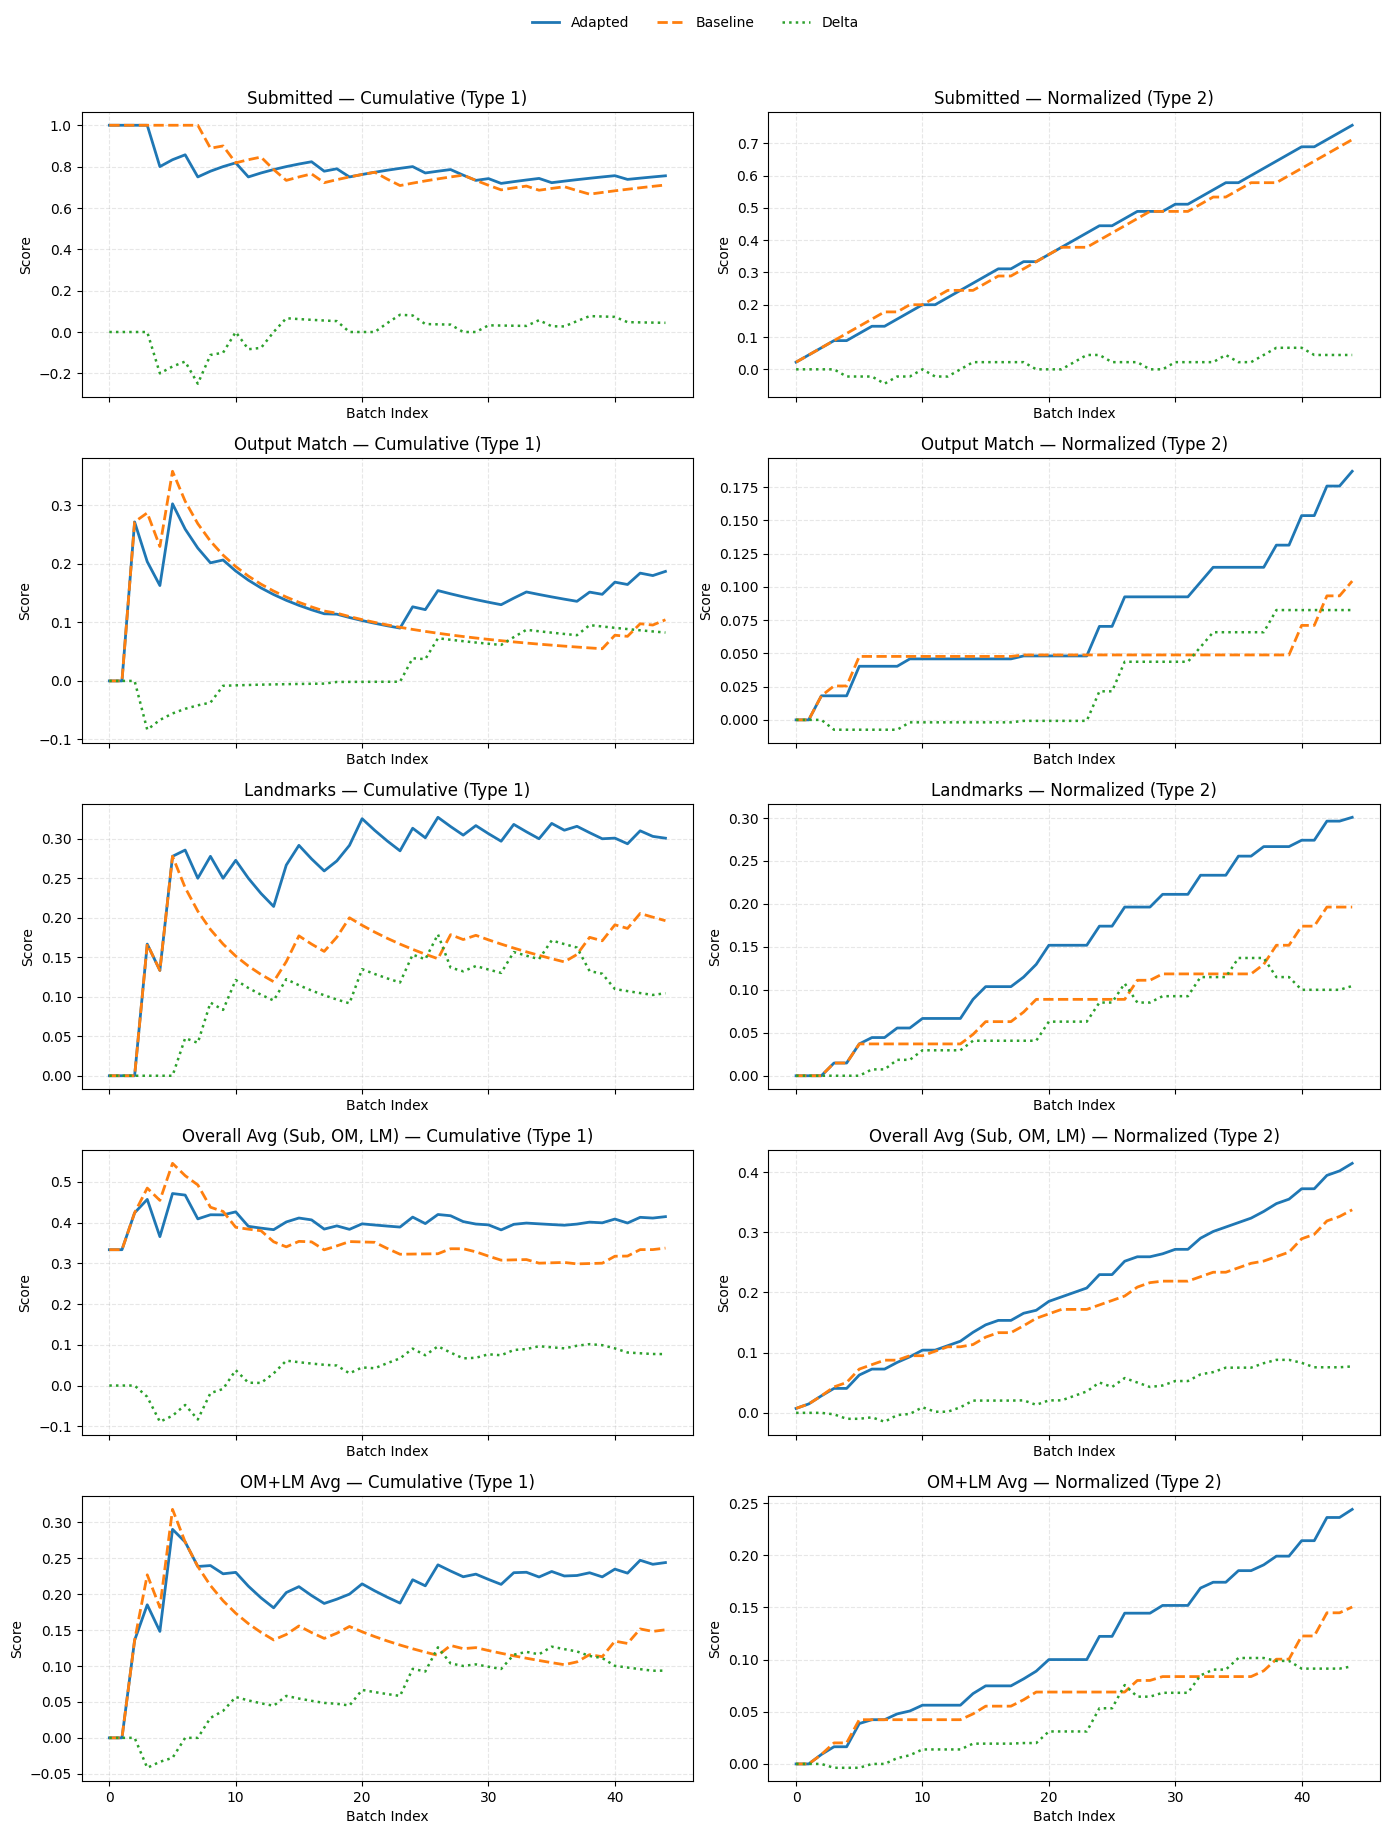

In [53]:
# Grid: 5 rows x 2 cols — Left: Type 1 (Cumulative), Right: Type 2 (Normalized)
# Rows: Submitted, Output Match, Landmarks, Overall Avg, OM+LM Avg
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'

# Ensure data is loaded
if 'batch_metrics' not in globals() or not batch_metrics:
    with open(analysis_out_path, 'r', encoding='utf-8') as f:
        batch_metrics = json.load(f)
        batch_metrics = {int(k): v for k, v in batch_metrics.items()}

xs = sorted(batch_metrics.keys())
N = len(xs) if len(xs) > 0 else 1

# Build per-batch series
ad_sub, ad_om, ad_lm = [], [], []
bs_sub, bs_om, bs_lm = [], [], []
for b in xs:
    e = batch_metrics[b]
    s = e.get('score') or {}
    bs = e.get('base_score') or {}
    ad_sub.append(float(s.get('submitted') or 0.0))
    ad_om.append(float(s.get('output_match') or 0.0))
    ad_lm.append(float(s.get('landmarks') or 0.0))
    bs_sub.append(float(bs.get('submitted') or 0.0))
    bs_om.append(float(bs.get('output_match') or 0.0))
    bs_lm.append(float(bs.get('landmarks') or 0.0))

def cum_avg_t1(arr):
    out, s = [], 0.0
    for i, v in enumerate(arr, start=1):
        s += v
        out.append(s / i)
    return out

def cum_avg_t2(arr, N):
    out, s = [], 0.0
    for i, v in enumerate(arr, start=1):
        s += v
        out.append(s / N)
    return out

def mk_series(ad, bs):
    ad_t1 = cum_avg_t1(ad)
    ad_t2 = cum_avg_t2(ad, N)
    bs_t1 = cum_avg_t1(bs)
    bs_t2 = cum_avg_t2(bs, N)
    d_t1 = [a - b for a, b in zip(ad_t1, bs_t1)]
    d_t2 = [a - b for a, b in zip(ad_t2, bs_t2)]
    return ad_t1, ad_t2, bs_t1, bs_t2, d_t1, d_t2

# Compute metric series
sub_t1, sub_t2, subb_t1, subb_t2, subd_t1, subd_t2 = mk_series(ad_sub, bs_sub)
om_t1,  om_t2,  omb_t1,  omb_t2,  omd_t1,  omd_t2  = mk_series(ad_om,  bs_om)
lm_t1,  lm_t2,  lmb_t1,  lmb_t2,  lmd_t1,  lmd_t2  = mk_series(ad_lm,  bs_lm)

ov_t1  = [(a + b + c) / 3.0 for a, b, c in zip(sub_t1, om_t1, lm_t1)]
ov_t2  = [(a + b + c) / 3.0 for a, b, c in zip(sub_t2, om_t2, lm_t2)]
ovb_t1 = [(a + b + c) / 3.0 for a, b, c in zip(subb_t1, omb_t1, lmb_t1)]
ovb_t2 = [(a + b + c) / 3.0 for a, b, c in zip(subb_t2, omb_t2, lmb_t2)]
ovd_t1 = [a - b for a, b in zip(ov_t1, ovb_t1)]
ovd_t2 = [a - b for a, b in zip(ov_t2, ovb_t2)]

omlm_t1  = [(a + b) / 2.0 for a, b in zip(om_t1, lm_t1)]
omlm_t2  = [(a + b) / 2.0 for a, b in zip(om_t2, lm_t2)]
omlmb_t1 = [(a + b) / 2.0 for a, b in zip(omb_t1, lmb_t1)]
omlmb_t2 = [(a + b) / 2.0 for a, b in zip(omb_t2, lmb_t2)]
omlmd_t1 = [a - b for a, b in zip(omlm_t1, omlmb_t1)]
omlmd_t2 = [a - b for a, b in zip(omlm_t2, omlmb_t2)]

def draw_row(ax_left, ax_right, title, ad_t1, bs_t1, d_t1, ad_t2, bs_t2, d_t2):
    # Left: Type 1 (Cumulative)
    ax_left.plot(xs, ad_t1, label='Adapted', color='#1f77b4', linestyle='-', linewidth=2.0)
    ax_left.plot(xs, bs_t1, label='Baseline', color='#ff7f0e', linestyle='--', linewidth=2.0)
    ax_left.plot(xs, d_t1,  label='Delta', color='#2ca02c', linestyle=':', linewidth=1.8)
    ax_left.set_title(f'{title} — Cumulative (Type 1)')
    ax_left.set_xlabel('Batch Index')
    ax_left.set_ylabel('Score')
    ax_left.grid(True, linestyle='--', alpha=0.3)

    # Right: Type 2 (Normalized)
    ax_right.plot(xs, ad_t2, label='Adapted', color='#1f77b4', linestyle='-', linewidth=2.0)
    ax_right.plot(xs, bs_t2, label='Baseline', color='#ff7f0e', linestyle='--', linewidth=2.0)
    ax_right.plot(xs, d_t2,  label='Delta', color='#2ca02c', linestyle=':', linewidth=1.8)
    ax_right.set_title(f'{title} — Normalized (Type 2)')
    ax_right.set_xlabel('Batch Index')
    ax_right.set_ylabel('Score')
    ax_right.grid(True, linestyle='--', alpha=0.3)

# Create grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 18), sharex='col')
(ax11, ax12), (ax21, ax22), (ax31, ax32), (ax41, ax42), (ax51, ax52) = axes

draw_row(ax11, ax12, 'Submitted', sub_t1, subb_t1, subd_t1, sub_t2, subb_t2, subd_t2)
draw_row(ax21, ax22, 'Output Match', om_t1, omb_t1, omd_t1, om_t2, omb_t2, omd_t2)
draw_row(ax31, ax32, 'Landmarks', lm_t1, lmb_t1, lmd_t1, lm_t2, lmb_t2, lmd_t2)
draw_row(ax41, ax42, 'Overall Avg (Sub, OM, LM)', ov_t1, ovb_t1, ovd_t1, ov_t2, ovb_t2, ovd_t2)
draw_row(ax51, ax52, 'OM+LM Avg', omlm_t1, omlmb_t1, omlmd_t1, omlm_t2, omlmb_t2, omlmd_t2)

# Single legend
handles, labels = ax11.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),  # center above subplots
    ncol=len(labels),           # or set manually
    frameon=False
)

fig.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()
